# Gamblers problem
### value iteration on the gamblers problem from sutton book to find the optimal policy

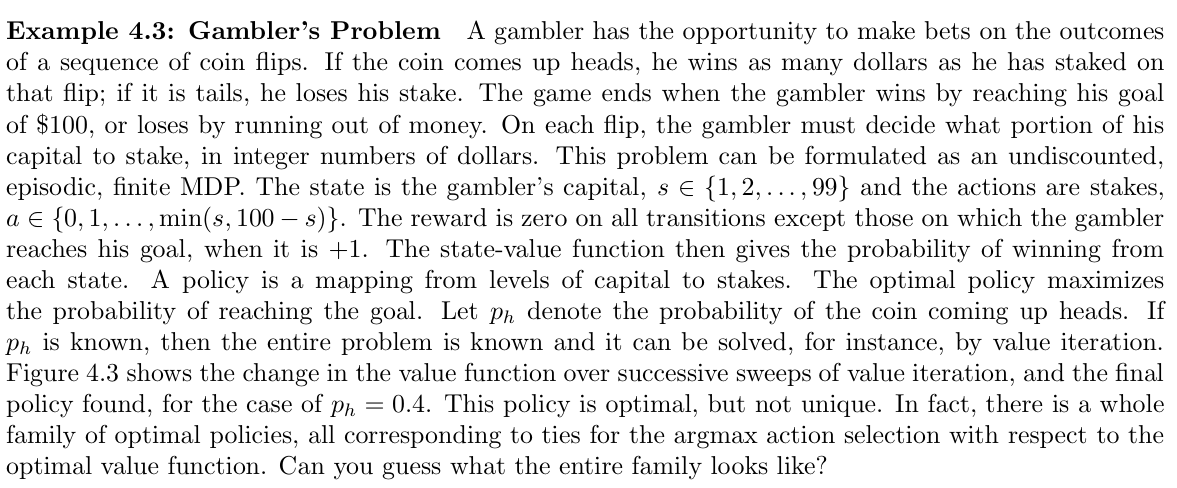

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [2]:
num_states=101
goal_state=100
end_state=0
goal_reward=+1
end_reward=0

ph=.4

In [3]:
def next_reward(state):
    if state>=goal_state:
        return goal_reward
    
    return end_reward

In [4]:
def val_iter(num_state, gamma, iterations=100):
    V=np.zeros(num_state)    
    for _ in range(iterations):
        new_v=np.zeros_like(V)
        for i in range (1,100):
            for action in range (0, min(i, 100-i)+1):
                new_v[i]=max(new_v[i], ph*(next_reward(i+action)+gamma*V[i+action]) + (1-ph)*(next_reward(i-action)+gamma*V[i-action]))
        V=new_v
    return V 
    

In [5]:
V_opt=val_iter(num_states, 1)
np.set_printoptions(precision=3, suppress=True)
print(V_opt)

[0.    0.002 0.005 0.009 0.013 0.017 0.023 0.028 0.032 0.038 0.043 0.05
 0.058 0.065 0.07  0.074 0.081 0.087 0.094 0.103 0.109 0.116 0.126 0.134
 0.144 0.16  0.163 0.168 0.174 0.179 0.186 0.195 0.202 0.208 0.217 0.225
 0.236 0.246 0.258 0.264 0.272 0.281 0.29  0.301 0.315 0.323 0.334 0.349
 0.36  0.376 0.4   0.403 0.408 0.414 0.419 0.426 0.435 0.442 0.448 0.457
 0.465 0.476 0.486 0.498 0.504 0.512 0.521 0.53  0.541 0.555 0.563 0.574
 0.589 0.6   0.616 0.64  0.645 0.652 0.661 0.669 0.679 0.692 0.703 0.713
 0.725 0.738 0.753 0.77  0.787 0.796 0.807 0.822 0.835 0.852 0.872 0.884
 0.901 0.923 0.941 0.964 0.   ]


In [28]:
def opt_p(num_state, gamma):
    P=np.zeros(num_state)
    for i in range (1,100):
        maxi=0
        for action in range (0, min(i, 100-i)+1):
            q=ph*(next_reward(i+action)+gamma*V_opt[i+action]) + (1-ph)*(next_reward(i-action)+gamma*V_opt[i-action])
            if(q>=maxi):
                P[i]=action
                maxi=q
    return P

In [29]:
P_opt=opt_p(num_states, 1)
np.set_printoptions(precision=3, suppress=True)
print(P_opt)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23.  1. 25. 26. 27. 28. 29.  5. 31. 32. 33. 16. 35.
 14. 12. 12. 39. 10. 41. 42. 43.  6.  5. 46.  3. 48. 49. 50.  1. 48. 47.
  0. 45. 44.  7. 42. 41. 40.  0. 38. 37. 14. 35. 34. 33. 32. 31. 30. 29.
 28. 27. 24. 25. 24. 23. 22. 21. 20. 19. 18. 17. 16. 15. 14. 13. 12. 11.
 10.  9.  8.  7.  6.  5.  4.  3.  0.  1.  0.]


TypeError: 'str' object is not callable

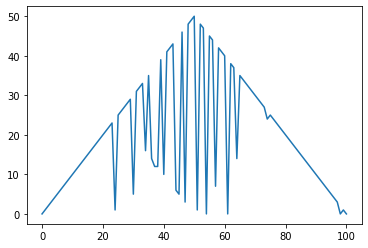

In [37]:
plt.plot(np.arange(0,101,1), P_opt)
plt.xlabel('capital')
plt.ylabel('stake')